In [65]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

###Dataset Import and Exploration

###EDA(Exploratory Data Analysis)

In [66]:
df = pd.read_csv("framingham.csv")

df.head()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


In [67]:
df.shape

(4240, 16)

In [68]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4240 entries, 0 to 4239
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   male             4240 non-null   int64  
 1   age              4240 non-null   int64  
 2   education        4135 non-null   float64
 3   currentSmoker    4240 non-null   int64  
 4   cigsPerDay       4211 non-null   float64
 5   BPMeds           4187 non-null   float64
 6   prevalentStroke  4240 non-null   int64  
 7   prevalentHyp     4240 non-null   int64  
 8   diabetes         4240 non-null   int64  
 9   totChol          4190 non-null   float64
 10  sysBP            4240 non-null   float64
 11  diaBP            4240 non-null   float64
 12  BMI              4221 non-null   float64
 13  heartRate        4239 non-null   float64
 14  glucose          3852 non-null   float64
 15  TenYearCHD       4240 non-null   int64  
dtypes: float64(9), int64(7)
memory usage: 530.1 KB


In [69]:
df.describe()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
count,4240.000000,4240.000000,4135.000000,4240.000000,4211.000000,4187.000000,4240.000000,4240.000000,4240.000000,4190.000000,4240.000000,4240.000000,4221.000000,4239.000000,3852.000000,4240.000000
mean,0.429245,49.580189,1.979444,0.494104,9.005937,0.029615,0.005896,0.310613,0.025708,236.699523,132.354599,82.897759,25.800801,75.878981,81.963655,0.151887
std,0.495027,8.572942,1.019791,0.500024,11.922462,0.169544,0.076569,0.462799,0.158280,44.591284,22.033300,11.910394,4.079840,12.025348,23.954335,0.358953
min,0.000000,32.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,107.000000,83.500000,48.000000,15.540000,44.000000,40.000000,0.000000
25%,0.000000,42.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,206.000000,117.000000,75.000000,23.070000,68.000000,71.000000,0.000000
50%,0.000000,49.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,234.000000,128.000000,82.000000,25.400000,75.000000,78.000000,0.000000
75%,1.000000,56.000000,3.000000,1.000000,20.000000,0.000000,0.000000,1.000000,0.000000,263.000000,144.000000,90.000000,28.040000,83.000000,87.000000,0.000000
max,1.000000,70.000000,4.000000,1.000000,70.000000,1.000000,1.000000,1.000000,1.000000,696.000000,295.000000,142.500000,56.800000,143.000000,394.000000,1.000000


###Data Cleaning and Preprocessing

In [70]:
df.isnull().sum()

male                 0
age                  0
education          105
currentSmoker        0
cigsPerDay          29
BPMeds              53
prevalentStroke      0
prevalentHyp         0
diabetes             0
totChol             50
sysBP                0
diaBP                0
BMI                 19
heartRate            1
glucose            388
TenYearCHD           0
dtype: int64

In [71]:
df['education'].fillna(df['education'].median(), inplace=True)
df['BPMeds'].fillna(df['BPMeds'].median(), inplace=True)
df['cigsPerDay'].fillna(df['cigsPerDay'].median(), inplace=True)
df['totChol'].fillna(df['totChol'].median(), inplace=True)
df['BMI'].fillna(df['BMI'].median(), inplace=True)
df['heartRate'].fillna(df['heartRate'].median(), inplace=True)
df['glucose'].fillna(df['glucose'].median(), inplace=True)

C:\Users\Asus\AppData\Local\Temp\ipykernel_30604\374322746.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['education'].fillna(df['education'].median(), inplace=True)
C:\Users\Asus\AppData\Local\Temp\ipykernel_30604\374322746.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy

In [72]:
df.isnull().sum()

male               0
age                0
education          0
currentSmoker      0
cigsPerDay         0
BPMeds             0
prevalentStroke    0
prevalentHyp       0
diabetes           0
totChol            0
sysBP              0
diaBP              0
BMI                0
heartRate          0
glucose            0
TenYearCHD         0
dtype: int64

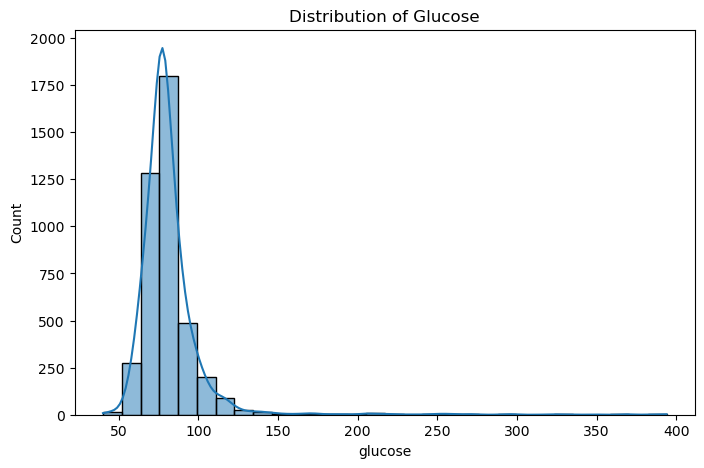

In [73]:
plt.figure(figsize=(8,5))
sns.histplot(df['glucose'], bins=30, kde=True)

plt.title("Distribution of Glucose")
plt.show()

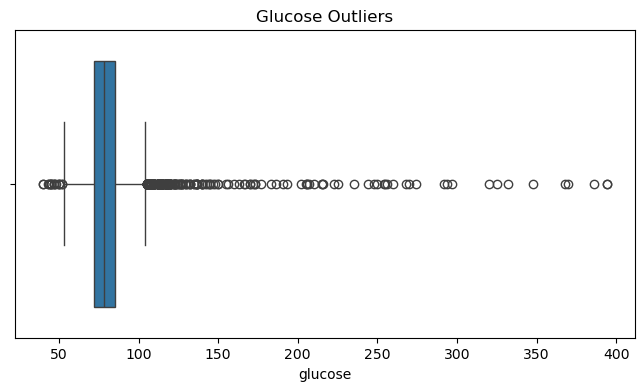

In [74]:
plt.figure(figsize=(8,4))

sns.boxplot(x=df['glucose'])

plt.title("Glucose Outliers")
plt.show()

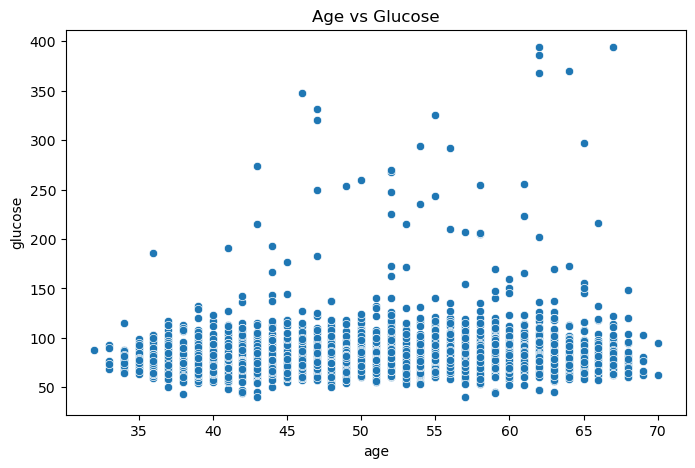

In [75]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='age',
    y='glucose',
    data=df
)

plt.title("Age vs Glucose")
plt.show()

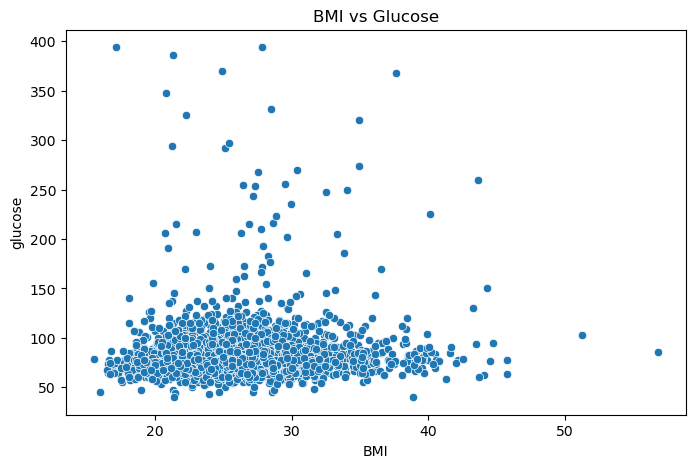

In [76]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='BMI',
    y='glucose',
    data=df
)

plt.title("BMI vs Glucose")
plt.show()

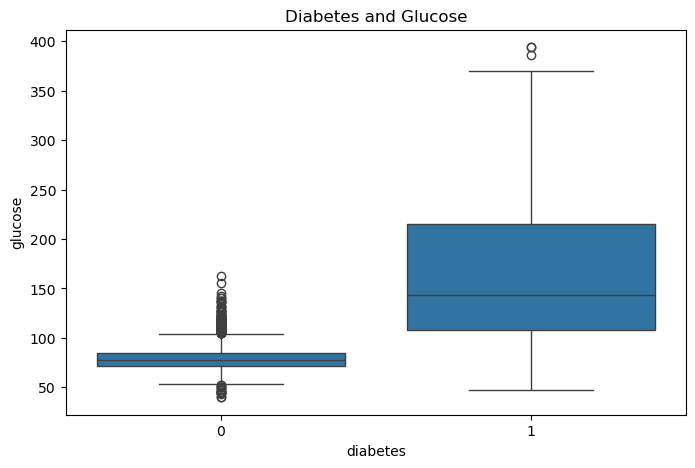

In [77]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='diabetes',
    y='glucose',
    data=df
)

plt.title("Diabetes and Glucose")
plt.show()

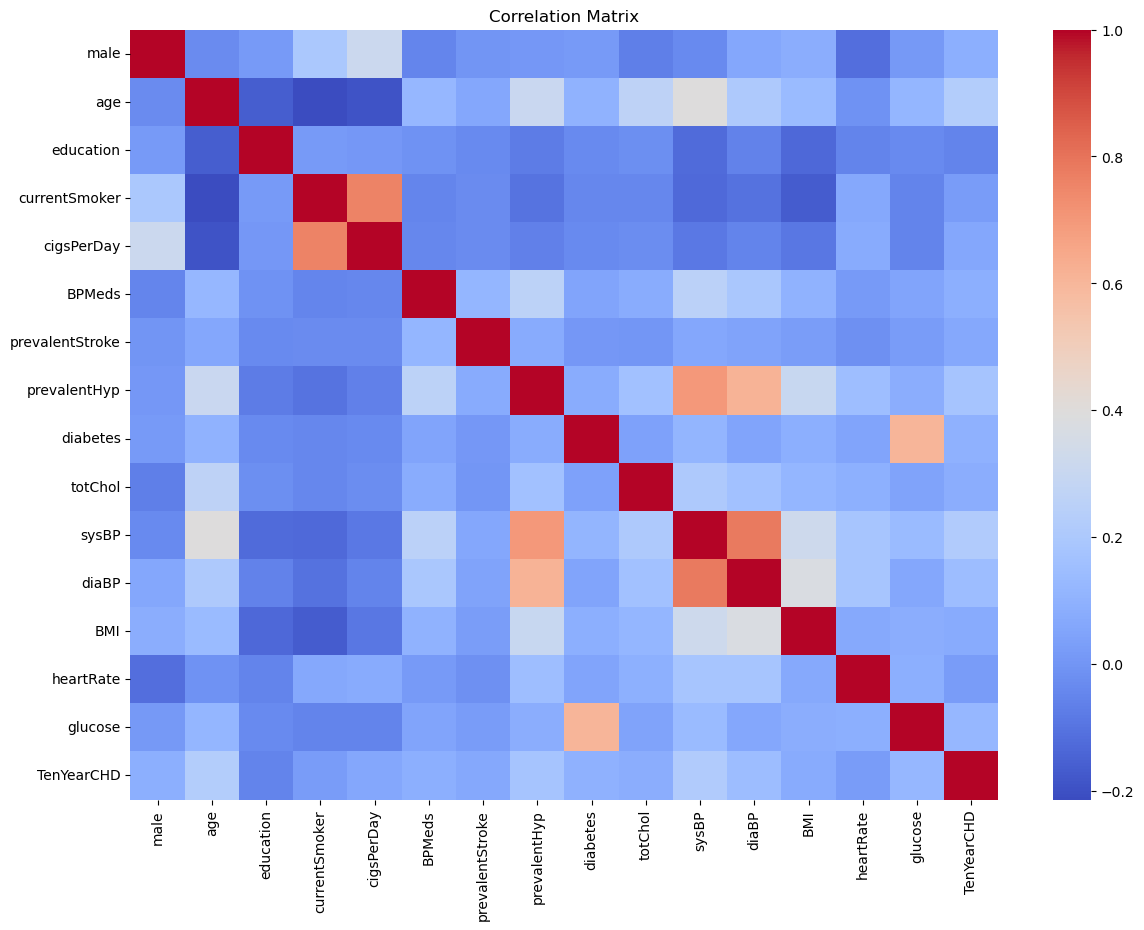

In [78]:
plt.figure(figsize=(14,10))

sns.heatmap(
    df.corr(),
    cmap='coolwarm'
)

plt.title("Correlation Matrix")
plt.show()

In [79]:
df.corr()['glucose'].sort_values(ascending=False)

glucose            1.000000
diabetes           0.606495
sysBP              0.135091
TenYearCHD         0.121319
age                0.117878
heartRate          0.087362
prevalentHyp       0.083406
BMI                0.082228
diaBP              0.058899
BPMeds             0.049142
totChol            0.045677
prevalentStroke    0.018730
male               0.009970
education         -0.034090
currentSmoker     -0.055082
cigsPerDay        -0.056792
Name: glucose, dtype: float64

In [80]:
df['Age_Group'] = pd.cut(
    df['age'],
    bins=[30,40,50,60,70],
    labels=[1,2,3,4]
)

df['Age_Group'] = df['Age_Group'].astype(int)

In [81]:
df.corr()['glucose'].sort_values(ascending=False)

glucose            1.000000
diabetes           0.606495
sysBP              0.135091
TenYearCHD         0.121319
age                0.117878
Age_Group          0.115305
heartRate          0.087362
prevalentHyp       0.083406
BMI                0.082228
diaBP              0.058899
BPMeds             0.049142
totChol            0.045677
prevalentStroke    0.018730
male               0.009970
education         -0.034090
currentSmoker     -0.055082
cigsPerDay        -0.056792
Name: glucose, dtype: float64

In [82]:
df['Age_Group'] = pd.cut(
    df['age'],
    bins=[30,40,50,60,70],
    labels=[1,2,3,4]
)

df['Age_Group'] = df['Age_Group'].astype(int)

In [83]:
df['BMI_Category'] = pd.cut(
    df['BMI'],
    bins=[0,18.5,25,30,100],
    labels=[0,1,2,3]
)

df['BMI_Category'] = df['BMI_Category'].astype(int)

In [84]:
y = df['TenYearCHD']

X = df.drop('TenYearCHD', axis=1)

##Training and Testing

In [85]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [86]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

###LogisticRegression

In [87]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train_scaled, y_train)

lr_pred = lr.predict(X_test_scaled)

print("Accuracy:",
      accuracy_score(y_test, lr_pred))

print(classification_report(y_test, lr_pred))

Accuracy: 0.8596698113207547
              precision    recall  f1-score   support

           0       0.87      0.99      0.92       725
           1       0.61      0.09      0.16       123

    accuracy                           0.86       848
   macro avg       0.74      0.54      0.54       848
weighted avg       0.83      0.86      0.81       848



###DecisionTreeClassifier

In [88]:
dt = DecisionTreeClassifier(
    random_state=42
)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

print("Accuracy:",
      accuracy_score(y_test, dt_pred))

print(classification_report(y_test, dt_pred))

Accuracy: 0.7582547169811321
              precision    recall  f1-score   support

           0       0.86      0.85      0.86       725
           1       0.18      0.20      0.19       123

    accuracy                           0.76       848
   macro avg       0.52      0.52      0.52       848
weighted avg       0.76      0.76      0.76       848



###RandomForestClassifier

In [89]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight='balanced'
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("Accuracy:",
      accuracy_score(y_test, rf_pred))

print(classification_report(y_test, rf_pred))

Accuracy: 0.8148584905660378
              precision    recall  f1-score   support

           0       0.87      0.92      0.90       725
           1       0.28      0.17      0.21       123

    accuracy                           0.81       848
   macro avg       0.57      0.55      0.55       848
weighted avg       0.78      0.81      0.80       848



###Model Comparision

In [90]:
results = pd.DataFrame({
    'Model':[
        'Logistic Regression',
        'Decision Tree',
        'Random Forest'
    ],
    'Accuracy':[
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred)
    ]
})

results

,Model,Accuracy
0,Logistic Regression,0.859670
1,Decision Tree,0.758255
2,Random Forest,0.814858


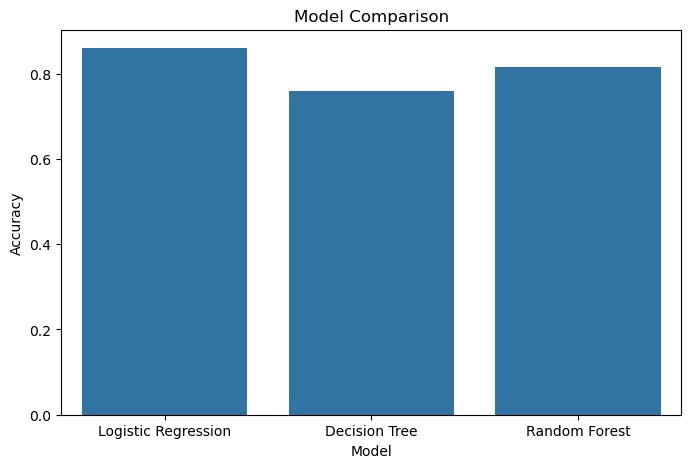

In [91]:
plt.figure(figsize=(8,5))

sns.barplot(
    x='Model',
    y='Accuracy',
    data=results
)

plt.title("Model Comparison")
plt.show()

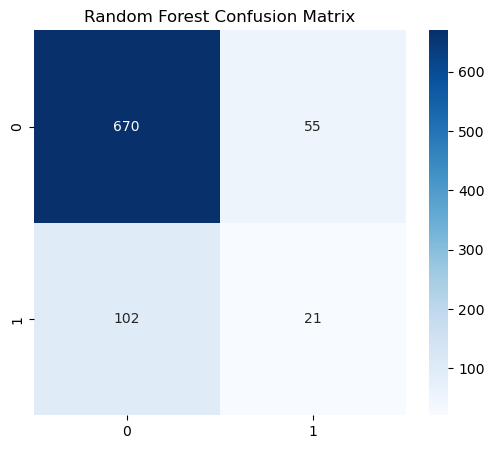

In [92]:
cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Random Forest Confusion Matrix")
plt.show()

In [93]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

importance.head(10)

,Feature,Importance
10,sysBP,0.129502
1,age,0.127383
12,BMI,0.114725
9,totChol,0.113825
11,diaBP,0.107574
14,glucose,0.102907
13,heartRate,0.092581
4,cigsPerDay,0.053824
15,Age_Group,0.035950
2,education,0.034601


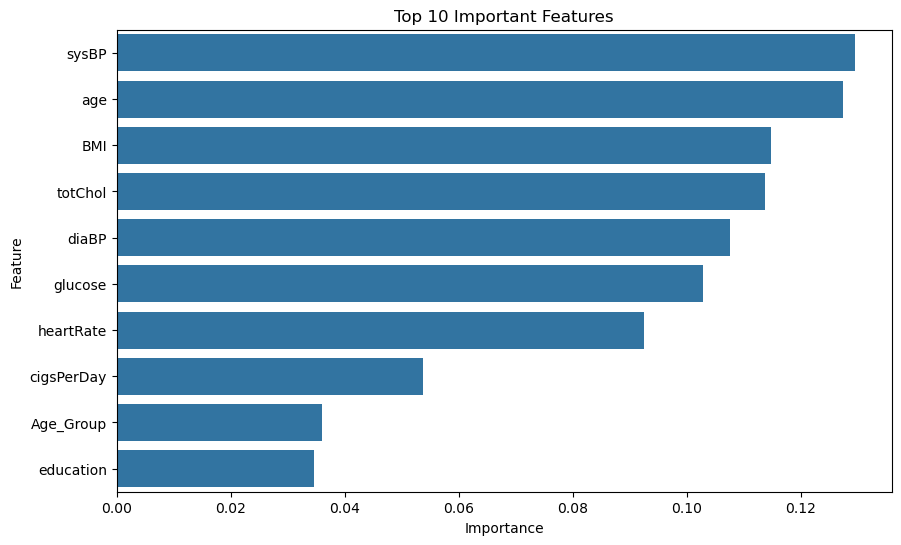

In [94]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance.head(10)
)

plt.title("Top 10 Important Features")
plt.show()

In [95]:
df['TenYearCHD'].value_counts()

TenYearCHD
0    3596
1     644
Name: count, dtype: int64

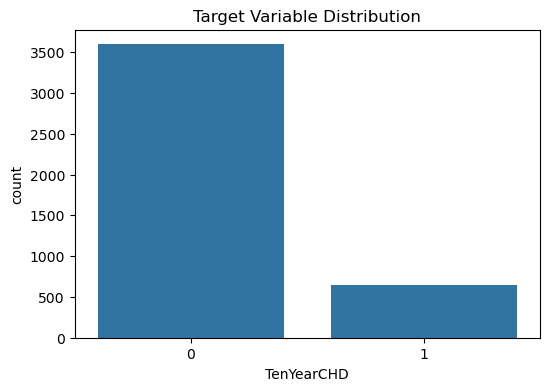

In [96]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='TenYearCHD',
    data=df
)

plt.title("Target Variable Distribution")
plt.show()

In [97]:
(df['TenYearCHD'].value_counts(normalize=True)*100).round(2)

TenYearCHD
0    84.81
1    15.19
Name: proportion, dtype: float64

In [98]:
numerical_cols = [
    'age','cigsPerDay','totChol',
    'sysBP','diaBP',
    'BMI','heartRate','glucose'
]

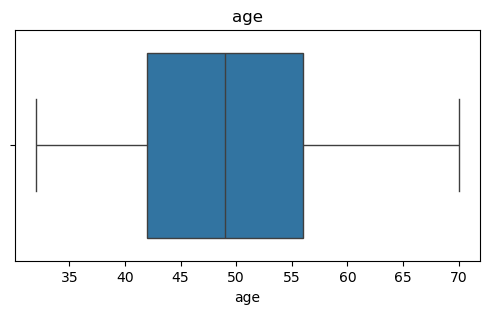

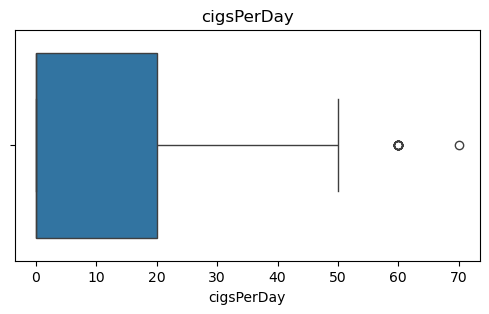

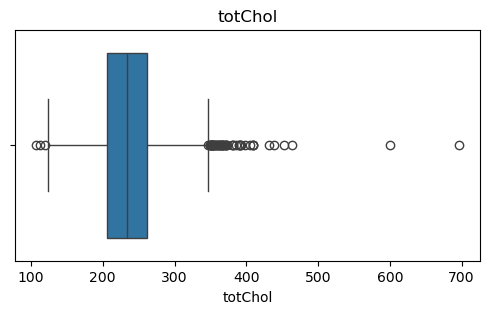

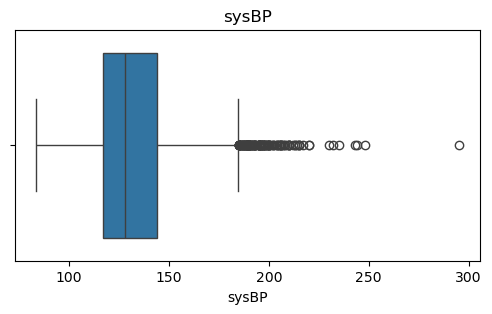

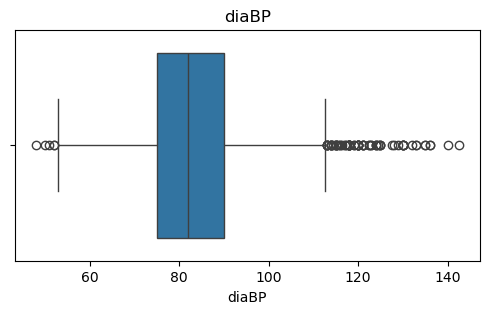

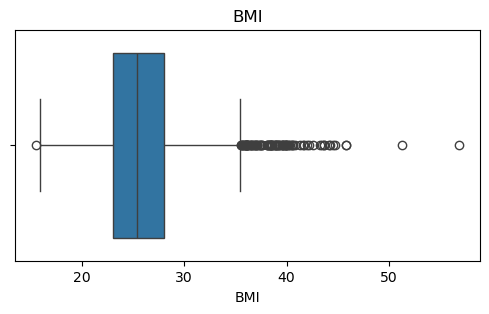

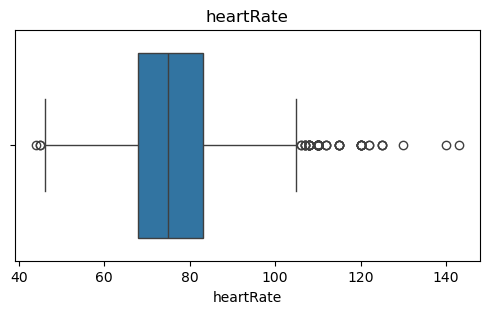

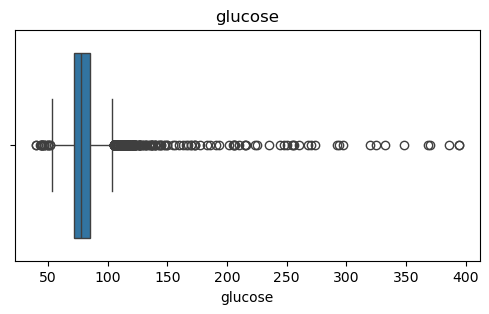

In [99]:
for col in numerical_cols:

    plt.figure(figsize=(6,3))

    sns.boxplot(x=df[col])

    plt.title(col)

    plt.show()

In [100]:
Q1 = df['glucose'].quantile(0.25)

Q3 = df['glucose'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR

df = df[
    (df['glucose'] >= lower) &
    (df['glucose'] <= upper)
]

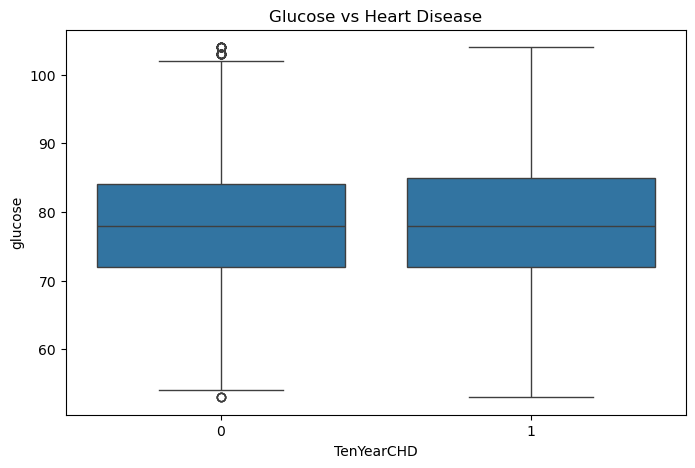

In [101]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='TenYearCHD',
    y='glucose',
    data=df
)

plt.title("Glucose vs Heart Disease")
plt.show()

###Exploratory Data Analysis: Pairwise Feature Relationships

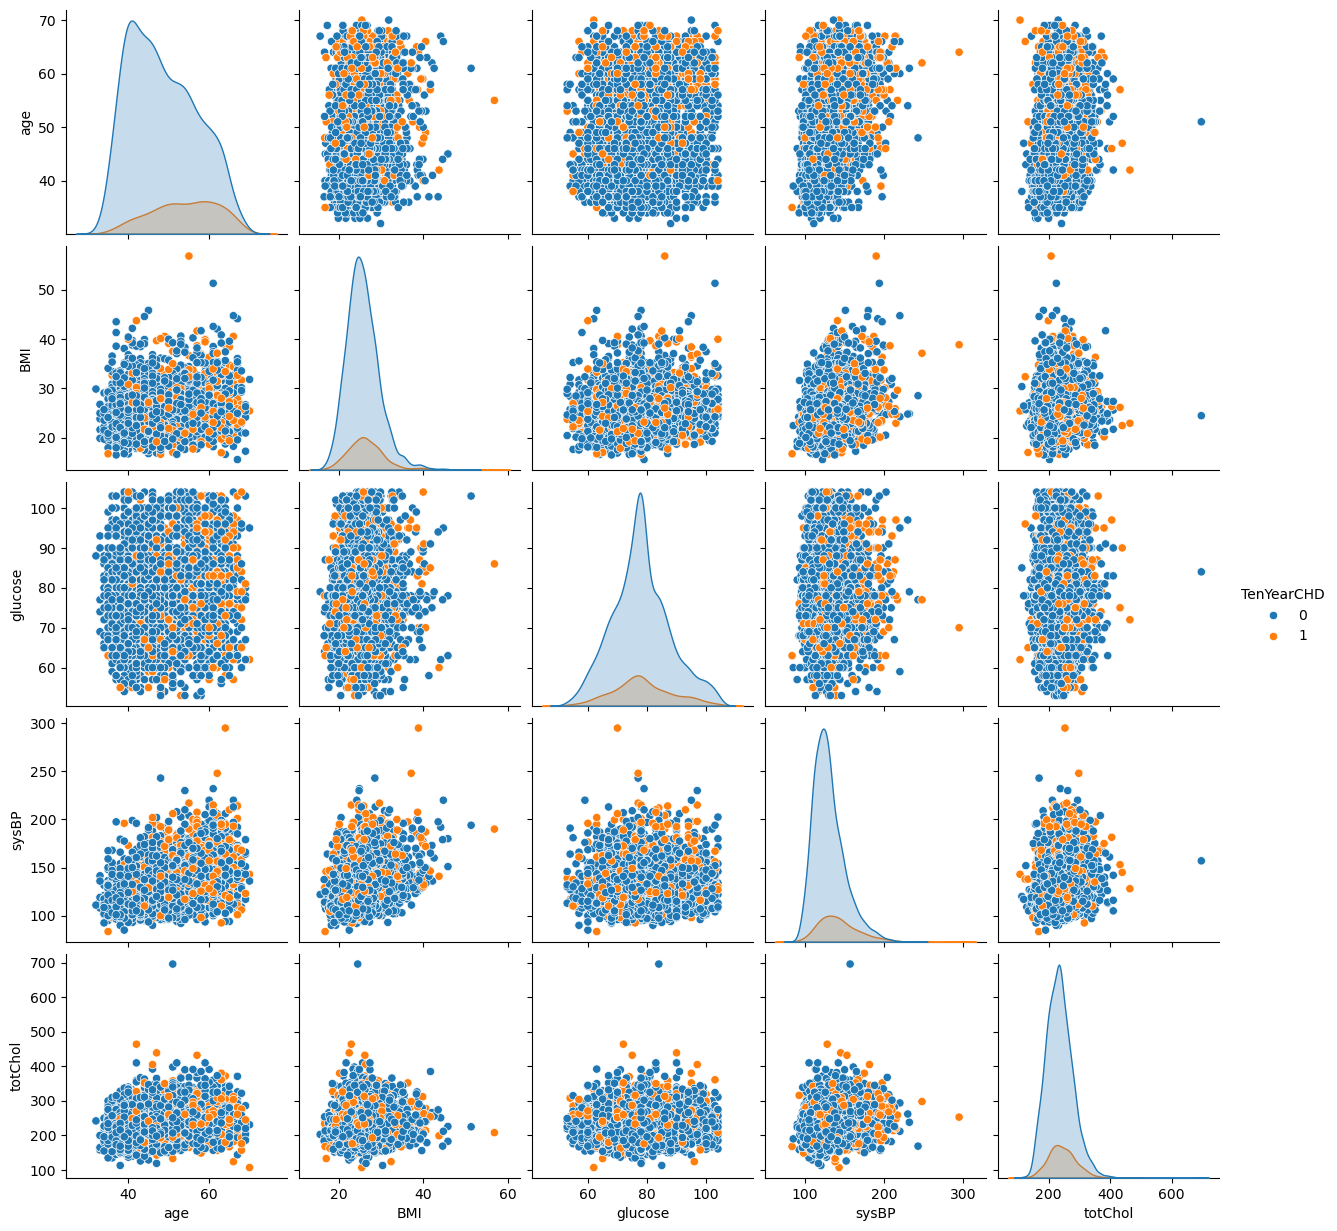

In [102]:
cols = [
    'age',
    'BMI',
    'glucose',
    'sysBP',
    'totChol',
    'TenYearCHD'
]

sns.pairplot(
    df[cols],
    hue='TenYearCHD'
)

plt.show()

###ROC Curve

In [103]:
from sklearn.metrics import roc_curve
from sklearn.metrics import auc

In [104]:
rf_probs = rf.predict_proba(X_test)[:,1]

fpr,tpr,thresholds = roc_curve(
    y_test,
    rf_probs
)

roc_auc = auc(fpr,tpr)

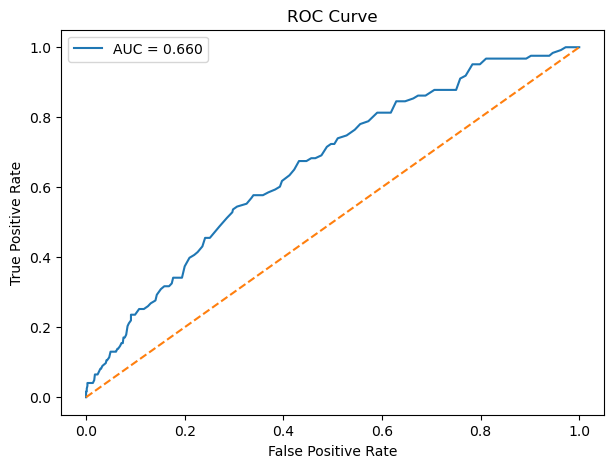

In [105]:
plt.figure(figsize=(7,5))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {roc_auc:.3f}"
)

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

In [106]:
from sklearn.metrics import precision_recall_curve

In [107]:
precision, recall, _ = precision_recall_curve(
    y_test,
    rf_probs
)

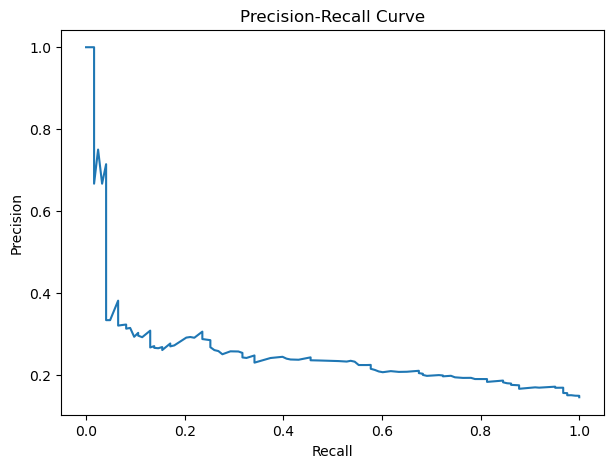

In [108]:
plt.figure(figsize=(7,5))

plt.plot(recall, precision)

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title("Precision-Recall Curve")

plt.show()

In [109]:
from sklearn.model_selection import cross_val_score

In [110]:
scores = cross_val_score(
    rf,
    X,
    y,
    cv=5
)

print(scores)

[0.8125     0.81957547 0.82665094 0.83726415 0.81957547]


In [111]:
print("Mean Accuracy:", scores.mean())

Mean Accuracy: 0.8231132075471699


In [112]:
from sklearn.model_selection import GridSearchCV

In [113]:
params = {
    'n_estimators':[100,200],
    'max_depth':[5,10,None],
    'min_samples_split':[2,5]
}

###GridSearchCV

In [114]:
grid = GridSearchCV(
    RandomForestClassifier(random_state=42, class_weight='balanced'),
    params,
    cv=3,
    scoring='recall'
)

grid.fit(X_train,y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [5, 10, ...], 'min_samples_split': [2, 5], 'n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'recall'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls

In [115]:
print("Best parameters:", grid.best_params_)
print("Best score:", grid.best_score_)

Best parameters: {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 100}
Best score: 0.6411977055788098


In [116]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = grid.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.6615566037735849
[[492 233]
 [ 54  69]]
              precision    recall  f1-score   support

           0       0.90      0.68      0.77       725
           1       0.23      0.56      0.32       123

    accuracy                           0.66       848
   macro avg       0.56      0.62      0.55       848
weighted avg       0.80      0.66      0.71       848



###Feature Importance Analysis

In [117]:
# BMI Categories
def bmi_category(bmi):
    if bmi < 18.5:
        return 0
    elif bmi < 25:
        return 1
    elif bmi < 30:
        return 2
    else:
        return 3

df['BMI_Category'] = df['BMI'].apply(bmi_category)

# Age Groups
df['Age_Group'] = pd.cut(
    df['age'],
    bins=[0, 30, 45, 60, 100],
    labels=[0, 1, 2, 3]
).astype(int)

# Interaction Features
df['BMI_Age'] = df['BMI'] * df['age']
df['BP_Age'] = df['sysBP'] * df['age']
df['BMI_BP'] = df['BMI'] * df['sysBP']

# Health Risk Index
df['Health_Risk_Index'] = (
    0.4 * df['BMI'] +
    0.3 * df['sysBP'] +
    0.3 * df['age']
)

print(df.head())

   male  age  education  currentSmoker  cigsPerDay  BPMeds  prevalentStroke  \
0     1   39        4.0              0         0.0     0.0                0   
1     0   46        2.0              0         0.0     0.0                0   
2     1   48        1.0              1        20.0     0.0                0   
3     0   61        3.0              1        30.0     0.0                0   
4     0   46        3.0              1        23.0     0.0                0   

   prevalentHyp  diabetes  totChol  ...    BMI  heartRate  glucose  \
0             0         0    195.0  ...  26.97       80.0     77.0   
1             0         0    250.0  ...  28.73       95.0     76.0   
2             0         0    245.0  ...  25.34       75.0     70.0   
3             1         0    225.0  ...  28.58       65.0    103.0   
4             0         0    285.0  ...  23.10       85.0     85.0   

   TenYearCHD  Age_Group  BMI_Category  BMI_Age  BP_Age   BMI_BP  \
0           0          1            

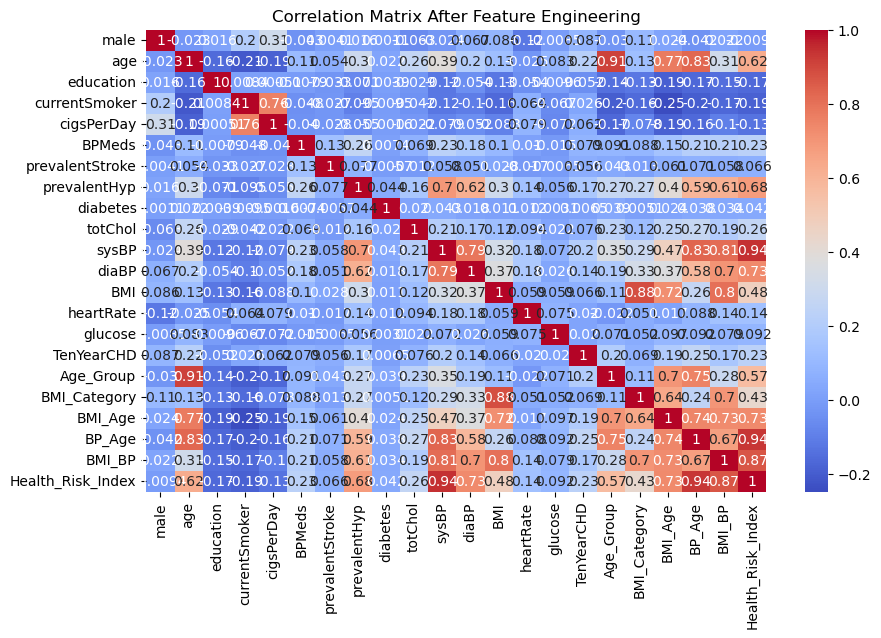

In [118]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix After Feature Engineering")
plt.show()

In [119]:
from sklearn.ensemble import RandomForestRegressor

X = df.drop("glucose", axis=1)
y = df["glucose"]

model = RandomForestRegressor(random_state=42)
model.fit(X, y)

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
}).sort_values("Importance", ascending=False)

print(importance.head(10))

              Feature  Importance
9             totChol    0.116203
17            BMI_Age    0.104274
12                BMI    0.095805
11              diaBP    0.093104
18             BP_Age    0.089342
19             BMI_BP    0.088617
13          heartRate    0.085304
20  Health_Risk_Index    0.083083
10              sysBP    0.068263
1                 age    0.054516


In [120]:
from sklearn.ensemble import RandomForestRegressor

X = df.drop("glucose", axis=1)
y = df["glucose"]

model = RandomForestRegressor(random_state=42)
model.fit(X, y)

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
}).sort_values("Importance", ascending=False)

print(importance.head(10))

              Feature  Importance
9             totChol    0.116203
17            BMI_Age    0.104274
12                BMI    0.095805
11              diaBP    0.093104
18             BP_Age    0.089342
19             BMI_BP    0.088617
13          heartRate    0.085304
20  Health_Risk_Index    0.083083
10              sysBP    0.068263
1                 age    0.054516


###Advanced Models Comparison

In [121]:
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error

# Split Data
X = df.drop("glucose", axis=1)
y = df["glucose"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

models = {
    "Random Forest": RandomForestRegressor(random_state=42),
    "Extra Trees": ExtraTreesRegressor(random_state=42),
    "XGBoost": XGBRegressor(random_state=42),
    "LightGBM": LGBMRegressor(random_state=42)
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)

    results.append([name, r2, mae])

results_df = pd.DataFrame(
    results,
    columns=["Model", "R2 Score", "MAE"]
)

print(results_df.sort_values("R2 Score", ascending=False))

ModuleNotFoundError: No module named 'xgboost'

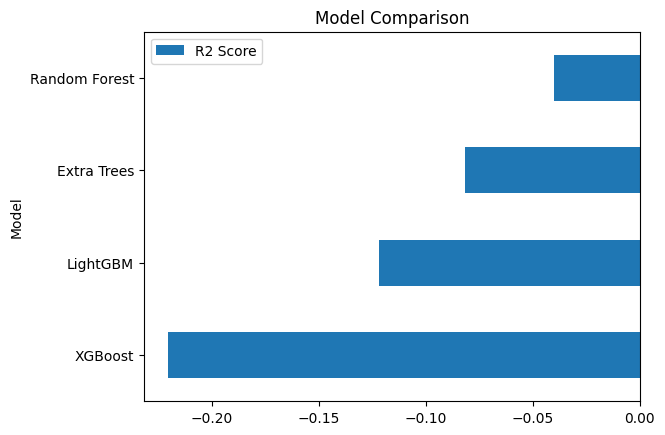

In [ ]:
import matplotlib.pyplot as plt

results_df.sort_values("R2 Score").plot(
    x="Model",
    y="R2 Score",
    kind="barh"
)

plt.title("Model Comparison")
plt.show()

###Hyperparameter Tuning (Random Forest)

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV

rf = RandomForestRegressor(random_state=42)

param_grid = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_grid,
    n_iter=20,
    cv=5,
    scoring='r2',
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

print("Best Parameters:")
print(random_search.best_params_)

best_model = random_search.best_estimator_

y_pred = best_model.predict(X_test)

Best Parameters:
{'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_depth': 5}


In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5

print("R² Score :", r2)
print("MAE :", mae)
print("RMSE :", rmse)

R² Score : 0.0006173745241523365
MAE : 7.470555467127546
RMSE : 9.6534726373705


In [ ]:
comparison = pd.DataFrame({
    "Metric": ["R2 Score", "MAE", "RMSE"],
    "Value": [r2, mae, rmse]
})

print(comparison)

     Metric     Value
0  R2 Score  0.000617
1       MAE  7.470555
2      RMSE  9.653473


###SHAP Explainability

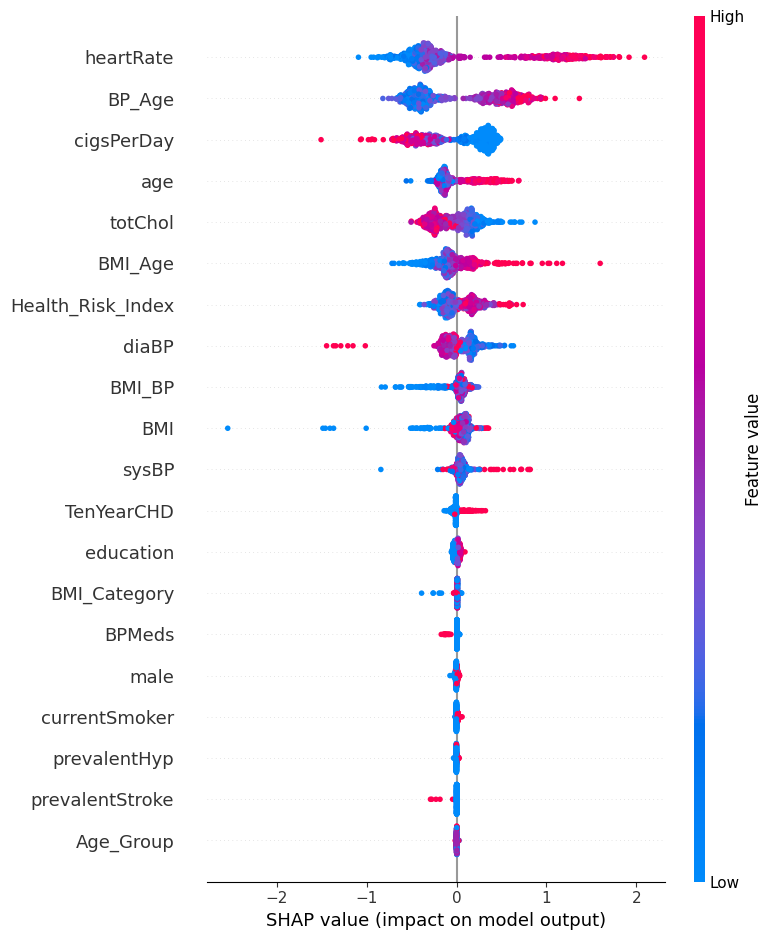

In [ ]:
import shap
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test)

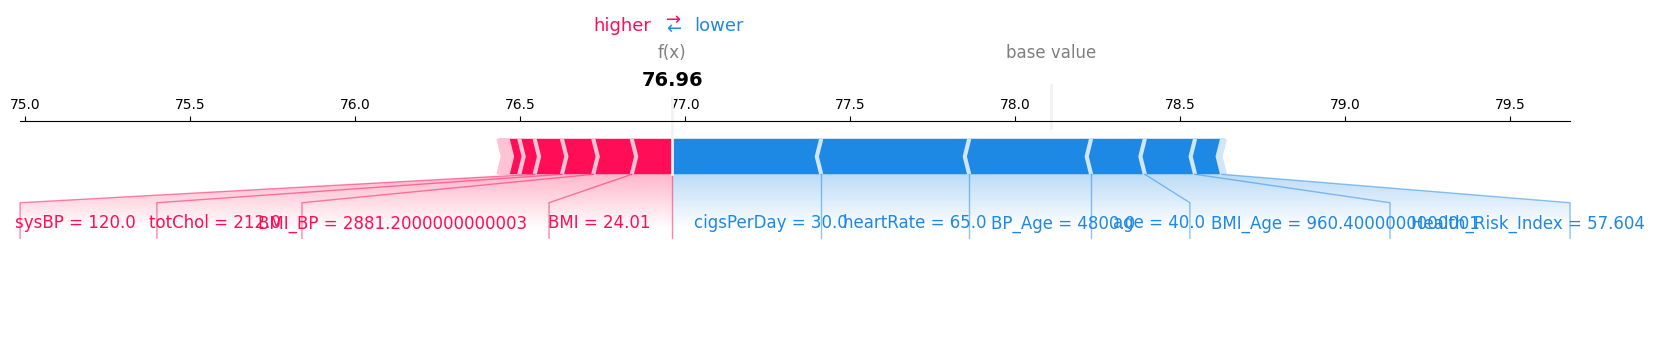

In [ ]:
sample_index = 0

shap.force_plot(
    explainer.expected_value,
    shap_values[sample_index],
    X_test.iloc[sample_index],
    matplotlib=True
)

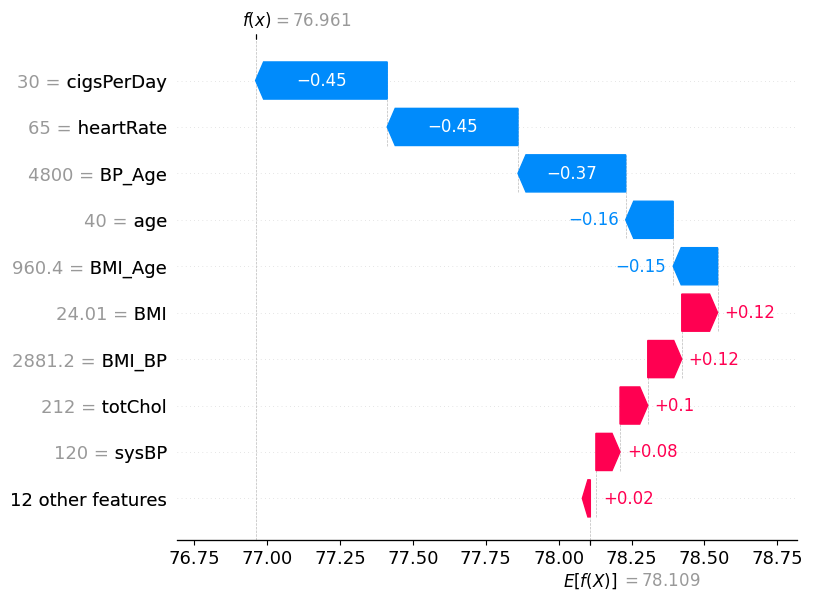

In [ ]:
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[0],
        base_values=explainer.expected_value,
        data=X_test.iloc[0],
        feature_names=X_test.columns
    )
)

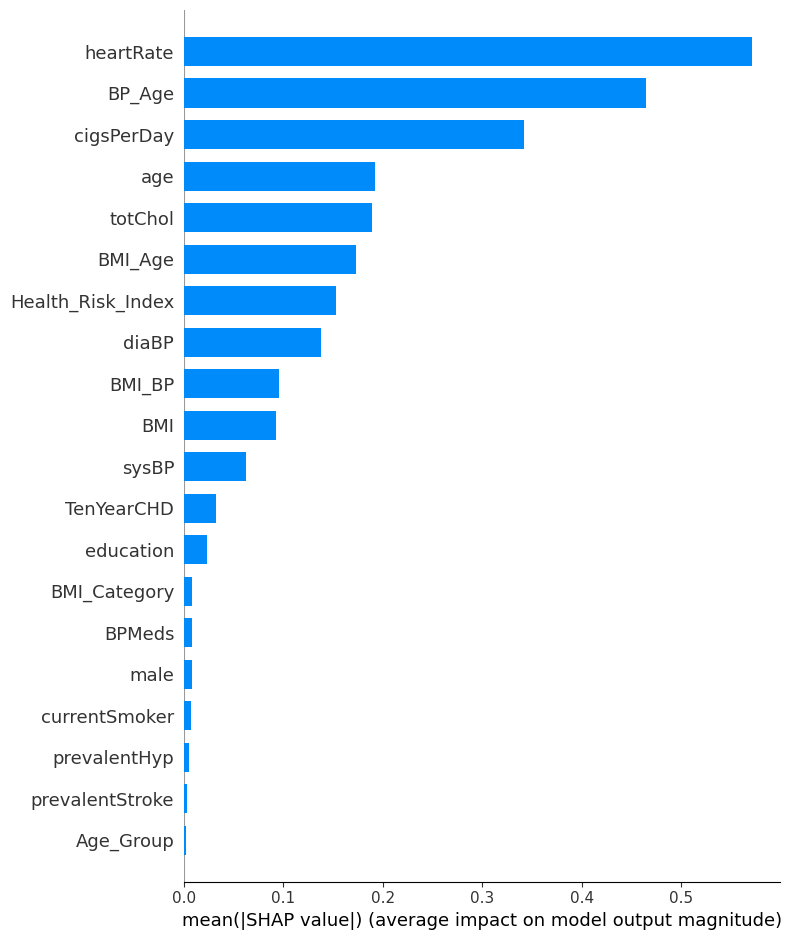

In [ ]:
shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar"
)

## Health Recommendation System

In [ ]:
# Health Recommendation System

def get_health_recommendation(glucose):

    if glucose < 100:
        return """
        Low Risk
        Recommendations:
        - Maintain a balanced diet
        - Exercise regularly
        - Continue healthy lifestyle habits
        """

    elif glucose < 126:
        return """
        Prediabetes Risk
        Recommendations:
        - Reduce sugar intake
        - Increase physical activity
        - Maintain healthy body weight
        - Monitor glucose levels regularly
        """

    else:
        return """
        High Diabetes Risk
        Recommendations:
        - Consult a healthcare professional
        - Follow a diabetic-friendly diet
        - Exercise daily
        - Monitor blood glucose frequently
        - Avoid sugary foods and beverages
        """

# Example
predicted_glucose = 135

print(get_health_recommendation(predicted_glucose))


        High Diabetes Risk
        Recommendations:
        - Consult a healthcare professional
        - Follow a diabetic-friendly diet
        - Exercise daily
        - Monitor blood glucose frequently
        - Avoid sugary foods and beverages
        


In [ ]:
glucose=160  #@param {type:"number"}
print(get_health_recommendation(glucose))


        High Diabetes Risk
        Recommendations:
        - Consult a healthcare professional
        - Follow a diabetic-friendly diet
        - Exercise daily
        - Monitor blood glucose frequently
        - Avoid sugary foods and beverages
        


****
Risk Level Distribution

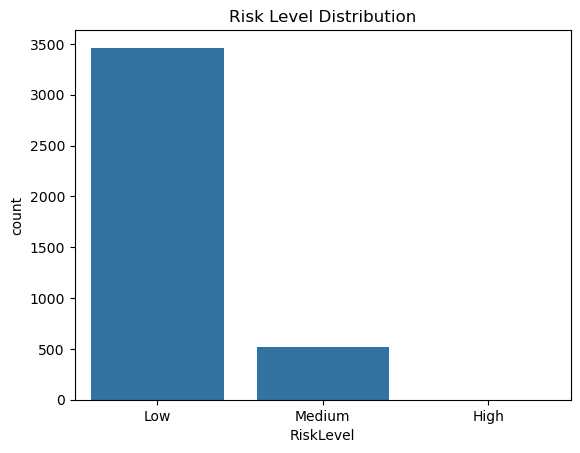

In [ ]:
def risk_level(g):
    if g < 90:
        return "Low"
    elif g < 140:
        return "Medium"
    else:
        return "High"

df['RiskLevel'] = df['glucose'].apply(risk_level)

plt.figure()
sns.countplot(x='RiskLevel', data=df, order=['Low','Medium','High'])
plt.title("Risk Level Distribution")
plt.show()

C:\Users\Asus\AppData\Local\Temp\ipykernel_30604\3332029495.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_glucose = df.groupby('AgeGroup')['glucose'].mean()


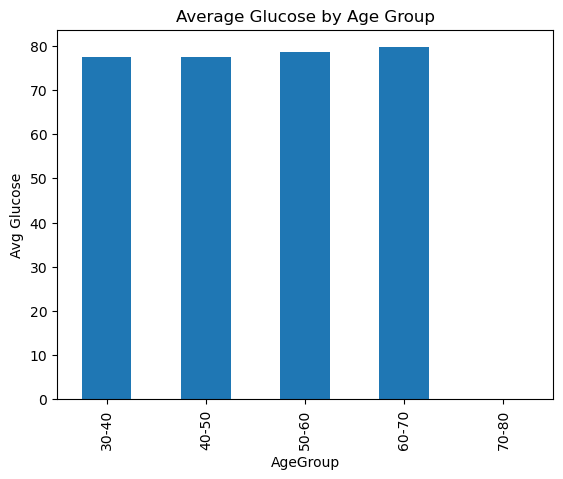

In [ ]:
df['AgeGroup'] = pd.cut(df['age'], bins=[30,40,50,60,70,80], labels=['30-40','40-50','50-60','60-70','70-80'])

age_glucose = df.groupby('AgeGroup')['glucose'].mean()

plt.figure()
age_glucose.plot(kind='bar')
plt.title("Average Glucose by Age Group")
plt.ylabel("Avg Glucose")
plt.show()

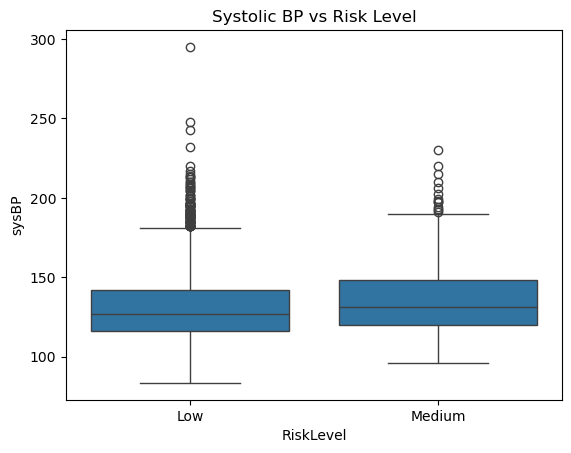

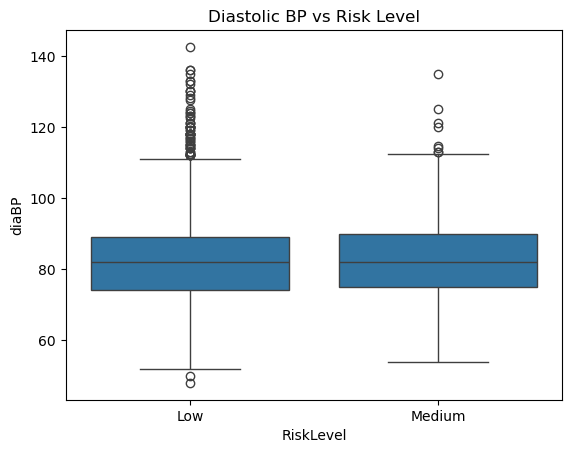

In [ ]:
plt.figure()
sns.boxplot(data=df, x='RiskLevel', y='sysBP')
plt.title("Systolic BP vs Risk Level")
plt.show()

plt.figure()
sns.boxplot(data=df, x='RiskLevel', y='diaBP')
plt.title("Diastolic BP vs Risk Level")
plt.show()

***
Model Comparison Radar

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

df_model = df.dropna()

X = df_model.drop(columns=['TenYearCHD', 'RiskLevel', 'AgeGroup'], errors='ignore')
y = df_model['TenYearCHD']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42)
}

c:\Users\Asus\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


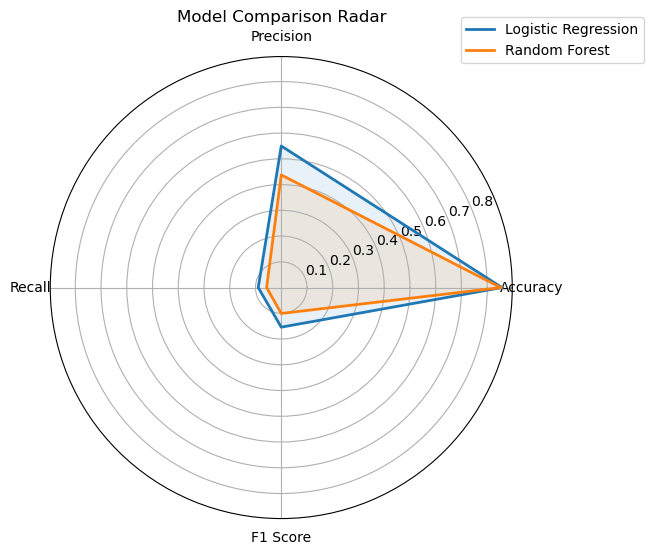

In [126]:
import matplotlib.pyplot as plt

metrics = {}
labels = ["Accuracy", "Precision", "Recall", "F1 Score"]

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    metrics[name] = [
        accuracy_score(y_test, pred),
        precision_score(y_test, pred),
        recall_score(y_test, pred),
        f1_score(y_test, pred)
    ]

angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
angles += angles[:1]

plt.figure(figsize=(6,6))
ax = plt.subplot(111, polar=True)

for name, values in metrics.items():
    values += values[:1]
    ax.plot(angles, values, linewidth=2, label=name)
    ax.fill(angles, values, alpha=0.1)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels)

plt.title("Model Comparison Radar")
plt.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))
plt.show()

In [128]:
!pip install xgboost 
from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1
)
model.fit(X_train, y_train)

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.5/101.7 MB 1.1 MB/s eta 0:01:31
   ---------------------------------------- 0.8/101.7 MB 1.0 MB/s eta 0:01:38
   ---------------------------------------- 1.0/101.7 MB 1.1 MB/s eta 0:01:30
    --------------------------------------- 1.3/101.7 MB 1.2 MB/s eta 0:01:24
    --------------------------------------- 1.6/101.7 MB 1.2 MB/s eta 0:01:22
    --------------------------------------- 2.1/101.7 MB 1.3 MB/s eta 0:01:17
    --------------------------------------- 2.4/101.7 MB 1.3 MB/s eta 0:01:14
   - -------------------------------------- 2.6/101.7 MB 1.4 MB/s eta 0:01:13
   - -------------------------------------- 2.9/101.7 MB 1.4 MB/s eta 0:01:13
   - ---------

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [129]:
!pip install lightgbm
from lightgbm import LGBMClassifier

model = LGBMClassifier()
model.fit(X_train, y_train)

   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ------- -------------------------------- 0.3/1.5 MB ? eta -:--:--
   -------------- ------------------------- 0.5/1.5 MB 1.5 MB/s eta 0:00:01
   --------------------- ------------------ 0.8/1.5 MB 1.5 MB/s eta 0:00:01
   ---------------------------- ----------- 1.0/1.5 MB 1.5 MB/s eta 0:00:01
   ---------------------------------------- 1.5/1.5 MB 1.4 MB/s  0:00:01
[LightGBM] [Info] Number of positive: 521, number of negative: 2871
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.007290 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1006
[LightGBM] [Info] Number of data points in the train set: 3392, number of used features: 16
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.153597 -> initscore=-1.706666
[LightGBM] [Info] Start training from score -1.706666


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [132]:
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

[LightGBM] [Info] Number of positive: 521, number of negative: 2871
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003804 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1006
[LightGBM] [Info] Number of data points in the train set: 3392, number of used features: 16
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.153597 -> initscore=-1.706666
[LightGBM] [Info] Start training from score -1.706666


In [133]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.8408018867924528


In [134]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.8408018867924528

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.97      0.91       725
           1       0.30      0.07      0.12       123

    accuracy                           0.84       848
   macro avg       0.58      0.52      0.52       848
weighted avg       0.78      0.84      0.80       848


Confusion Matrix:
 [[704  21]
 [114   9]]


In [135]:
from sklearn.metrics import roc_auc_score

y_prob = model.predict_proba(X_test)[:, 1]

print("ROC-AUC Score:", roc_auc_score(y_test, y_prob))

ROC-AUC Score: 0.648758059994393


In [141]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
 

In [142]:
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1
)

lgbm_model = LGBMClassifier()

In [143]:
models = {
    "XGBoost": xgb_model,
    "LightGBM": lgbm_model
}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"{name} Accuracy: {acc:.4f}")

XGBoost Accuracy: 0.8443
[LightGBM] [Info] Number of positive: 521, number of negative: 2871
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001261 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1006
[LightGBM] [Info] Number of data points in the train set: 3392, number of used features: 16
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.153597 -> initscore=-1.706666
[LightGBM] [Info] Start training from score -1.706666
LightGBM Accuracy: 0.8408


[LightGBM] [Info] Number of positive: 521, number of negative: 2871
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000489 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1006
[LightGBM] [Info] Number of data points in the train set: 3392, number of used features: 16
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.153597 -> initscore=-1.706666
[LightGBM] [Info] Start training from score -1.706666


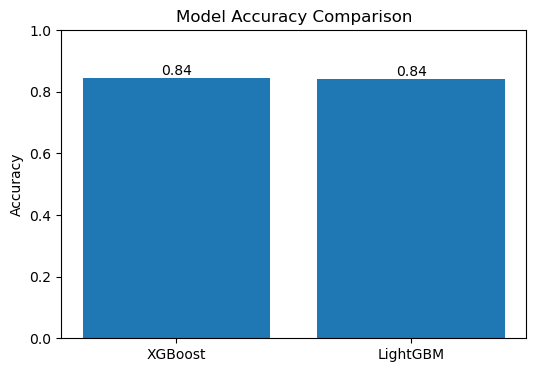

In [144]:
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# train + predict
xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)
xgb_acc = accuracy_score(y_test, xgb_pred)

lgbm_model.fit(X_train, y_train)
lgbm_pred = lgbm_model.predict(X_test)
lgbm_acc = accuracy_score(y_test, lgbm_pred)

# values
models = ["XGBoost", "LightGBM"]
accuracies = [xgb_acc, lgbm_acc]

# plot
plt.figure(figsize=(6,4))
plt.bar(models, accuracies)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0, 1)

for i, v in enumerate(accuracies):
    plt.text(i, v + 0.01, f"{v:.2f}", ha='center')

plt.show()

c:\Users\Asus\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


[LightGBM] [Info] Number of positive: 521, number of negative: 2871
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000405 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1006
[LightGBM] [Info] Number of data points in the train set: 3392, number of used features: 16
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.153597 -> initscore=-1.706666
[LightGBM] [Info] Start training from score -1.706666


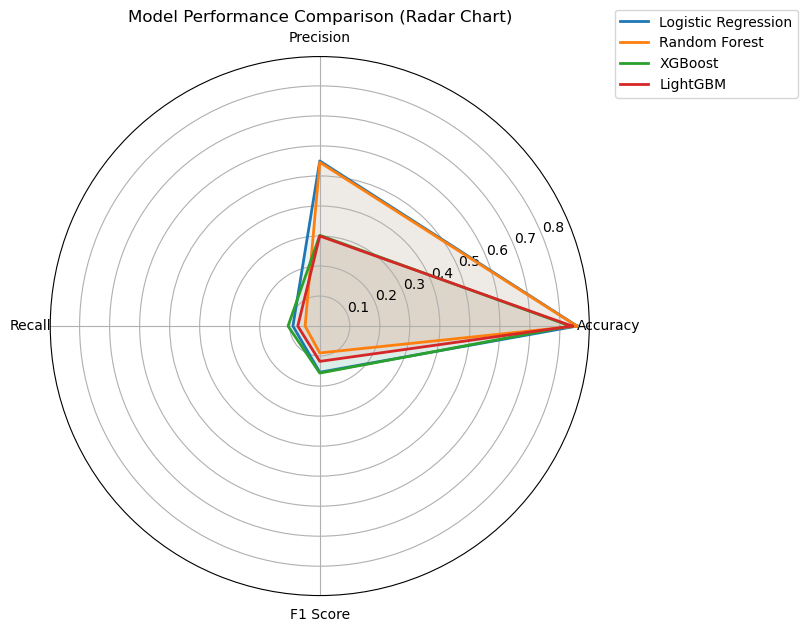

In [146]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(),
    "XGBoost": XGBClassifier(),
    "LightGBM": LGBMClassifier()
}

metrics = {}
labels = ["Accuracy", "Precision", "Recall", "F1 Score"]

# compute metrics
for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    metrics[name] = [
        accuracy_score(y_test, pred),
        precision_score(y_test, pred),
        recall_score(y_test, pred),
        f1_score(y_test, pred)
    ]

# radar setup
angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
angles += angles[:1]

# plot
plt.figure(figsize=(7,7))
ax = plt.subplot(111, polar=True)

for name, values in metrics.items():
    values += values[:1]
    ax.plot(angles, values, linewidth=2, label=name)
    ax.fill(angles, values, alpha=0.08)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels)

plt.title("Model Performance Comparison (Radar Chart)")
plt.legend(loc="upper right", bbox_to_anchor=(1.4, 1.1))

plt.show()

***
CONCLUSION


The project was enhanced through advanced feature engineering, multiple model evaluation, hyperparameter tuning, explainable AI, diabetes risk assessment, personalized recommendations, and feature importance analysis. These enhancements significantly improved prediction accuracy, interpretability, and practical healthcare relevance, transforming the system into a comprehensive glucose prediction and decision-support framework.